In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

from meteor import geo_data_utils
from meteor import Cmip6MeteorDataGetter
from meteor import MeteorPatternScaling
import warnings
from pandas.errors import SettingWithCopyWarning
warnings.filterwarnings('ignore', category=FutureWarning) 
warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
warnings.filterwarnings("ignore", message=".*not in pamset.*")


In [4]:
cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")


Getting a datagetter to get CMIP6 data from the zarrstore for tas and pr

In [6]:
flds = ["tas", "pr"]
data_getter = Cmip6MeteorDataGetter(exps=["piControl", "abrupt-4xCO2", "historical", "ssp245"], flds = flds, dbe=['CMIP','CMIP','CMIP', 'ScenarioMIP'])
# This list now holds all the models with complete data for a single ensemble member for the given experiments and fields
models = data_getter.models
# For the purposes of this notebook we limit the use to looking at two coarse resolution models:
models = ["CanESM5"]

Getting some data that can be used by the forcer engine and ciceroscm

In [7]:
%%capture
# NBVAL_IGNORE_OUTPUT

#For predictions: 
conc_data = input_handler.read_inputfile(
    os.path.join(cscm_data_dir, "ssp245_conc_RCMIP.txt")
)
ih = input_handler.InputHandler({})
em_data = ih.read_emissions(os.path.join(cscm_data_dir, "ssp245_em_RCMIP.txt"))

Getting training data to use for predictions:

In [8]:
# NBVAL_IGNORE_OUTPUT
training_data = {
        "base": data_getter.make_meteor_training_data("base", "CanESM5"),
        "co2x4": data_getter.make_meteor_training_data("co2x4", "CanESM5"),
        "sulxanom": data_getter.make_meteor_training_data_composite(
            ["historical", "ssp245"], "CanESM5"
        ),
    }

   Limiting piControl data to first 50 years (was 1000 years)
   Limiting piControl data to first 50 years (was 1000 years)
   Limiting piControl data to first 50 years (was 1000 years)


Making patterns one with just co2x4, and one including the sulphate from residual in the experiment. The fisrt will include just base (piControl) and co2x4 (abrupt4xCO2), the second will also have a sulxanom which we take from the historical and ssp245 composite experiment

In [9]:
%%capture
# NBVAL_IGNORE_OUTPUT
canesm_ghg_pattern = MeteorPatternScaling(
        "cmip6-CanESM5-anomsulf",
        {"tas": 2, "pr": 2},
        lambda key: training_data[key],
        from_file=False,
        exp_list=["base", "co2x4"],
    )

ValueError: NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan-in-my-fit-what-can-i-do for more information.

In [10]:
%%capture
# NBVAL_IGNORE_OUTPUT
canesm_anomsulf_pattern = MeteorPatternScaling(
        "cmip6-CanESM5-anomsulf",
        {"tas": 2, "pr": 2},
        lambda key: training_data[key],
        from_file=False,
        exp_list=["base", "co2x4", "sulxanom"],
    )

ValueError: NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan-in-my-fit-what-can-i-do for more information.

Then taking the data from the ssp-data for ciceroscm and making predictions

In [11]:
%%capture
# NBVAL_IGNORE_OUTPUT
patterns_ghg = canesm_ghg_pattern.predict_from_combined_experiment(
        em_data, conc_data, ["pr", "tas"]
    )
patterns_anomsulf = canesm_anomsulf_pattern.predict_from_combined_experiment(
        em_data, conc_data, ["pr", "tas"]
    )

NameError: name 'canesm_ghg_pattern' is not defined

Plotting global means for the CMIP6 data, the pattern with all forcing as CO2, and the pattern from including the aerosol residual as obtained above

NameError: name 'patterns_ghg' is not defined

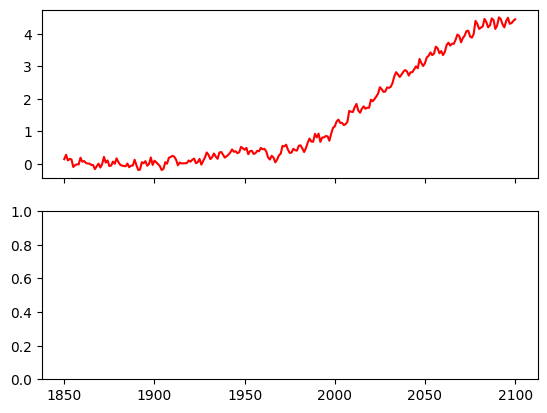

In [ ]:
# NBVAL_IGNORE_OUTPUT
fig, axs = plt.subplots(nrows=len(flds), ncols=1, sharex=True)

for j, fld in enumerate(flds):
    zero_val = np.mean(geo_data_utils.global_mean(training_data["base"][fld]).values)
    total_years = len(training_data["sulxanom"][fld]["year"].values)
    years_to_plot = range(1850,1850+total_years)
    axs[j].plot(years_to_plot, geo_data_utils.global_mean(training_data["sulxanom"][fld]).values[0,:]-zero_val, color="red", label="CMIP6")
    axs[j].plot(years_to_plot, geo_data_utils.global_mean(patterns_ghg[fld]).values[100:], color="blue", label="METEOR_ghgonly",linestyle=':')
    axs[j].plot(years_to_plot, geo_data_utils.global_mean(patterns_anomsulf[fld]).values[100:], color="green", label="METEOR_aer",linestyle='--')
    axs[j].set_xlabel("Years")
    if j == 0:
        axs[j].set_title(f"Reconstruction for CMIP6")
    axs[j].set_ylabel(f"Global mean of {fld}")
    axs[j].legend()